In [ ]:
%pip install puremacro


# Empirical Benchmark Replications — Galí (1999) & Mertens-Ravn (2013)

**How do fundamental macroeconomic shocks — technology and fiscal taxes — affect output, labor, and monetary policy in empirical data?**

In this interactive showcase, we replicate two milestone empirical identification strategies using `puremacro.datasets`:

1. **Galí (1999, *AER*) Long-Run Restrictions (Blanchard-Quah)**:
   - Tests the Real Business Cycle (RBC) prediction that technology shocks expand hours worked.
   - Identifies technology as the sole shock with a permanent long-run effect on labor productivity ($Y/N$).
   - Replicates the famous finding: hours worked *fall* on impact in response to a positive technology shock, supporting sticky-price New Keynesian models over standard RBC models.

2. **Mertens & Ravn (2013, *AER*) External Instruments (Proxy SVAR)**:
   - Identifies unanticipated tax multiplier shocks using narrative historical tax liabilities as external instruments ($z_t$).
   - Traces the contractionary impact of tax hikes on real GDP and the Federal Reserve's monetary reaction function.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.datasets import load_gali1999, load_narrative_tax_shocks, load_macro_quarterly
from puremacro.var.identify import bq, proxy

## 1. Replicating Galí (1999, AER): Technology Shocks and Hours Worked

We load the quarterly US dataset (1948Q2–1994Q4) with labor productivity growth (`dlprod`) and log hours worked (`hours`).

In [2]:
df_gali = load_gali1999()
print("Galí (1999) Dataset Preview:")
print(df_gali[["dlprod", "hours"]].head())

# Estimate VAR(4) with long-run BQ restriction
Z_gali = df_gali[["dlprod", "hours"]].to_numpy(dtype=float)
bq_res = bq(Z_gali, p=4, horizon=20)
print("\n" + bq_res.summary())

Galí (1999) Dataset Preview:
          dlprod       hours
date                        
1948Q2 -0.264453 -779.065310
1948Q3  0.108467 -778.686651
1948Q4  0.437013 -779.770959
1949Q1  1.013754 -781.629822
1949Q2  1.024734 -783.535804

Blanchard-Quah SVAR result
  variables (n)     : 2
  horizon (H)       : 20
  CI level          : 0.90
  bootstrap draws   : 500 (dropped 0, 0.0%)



### Impulse Responses to a Positive Technology Shock

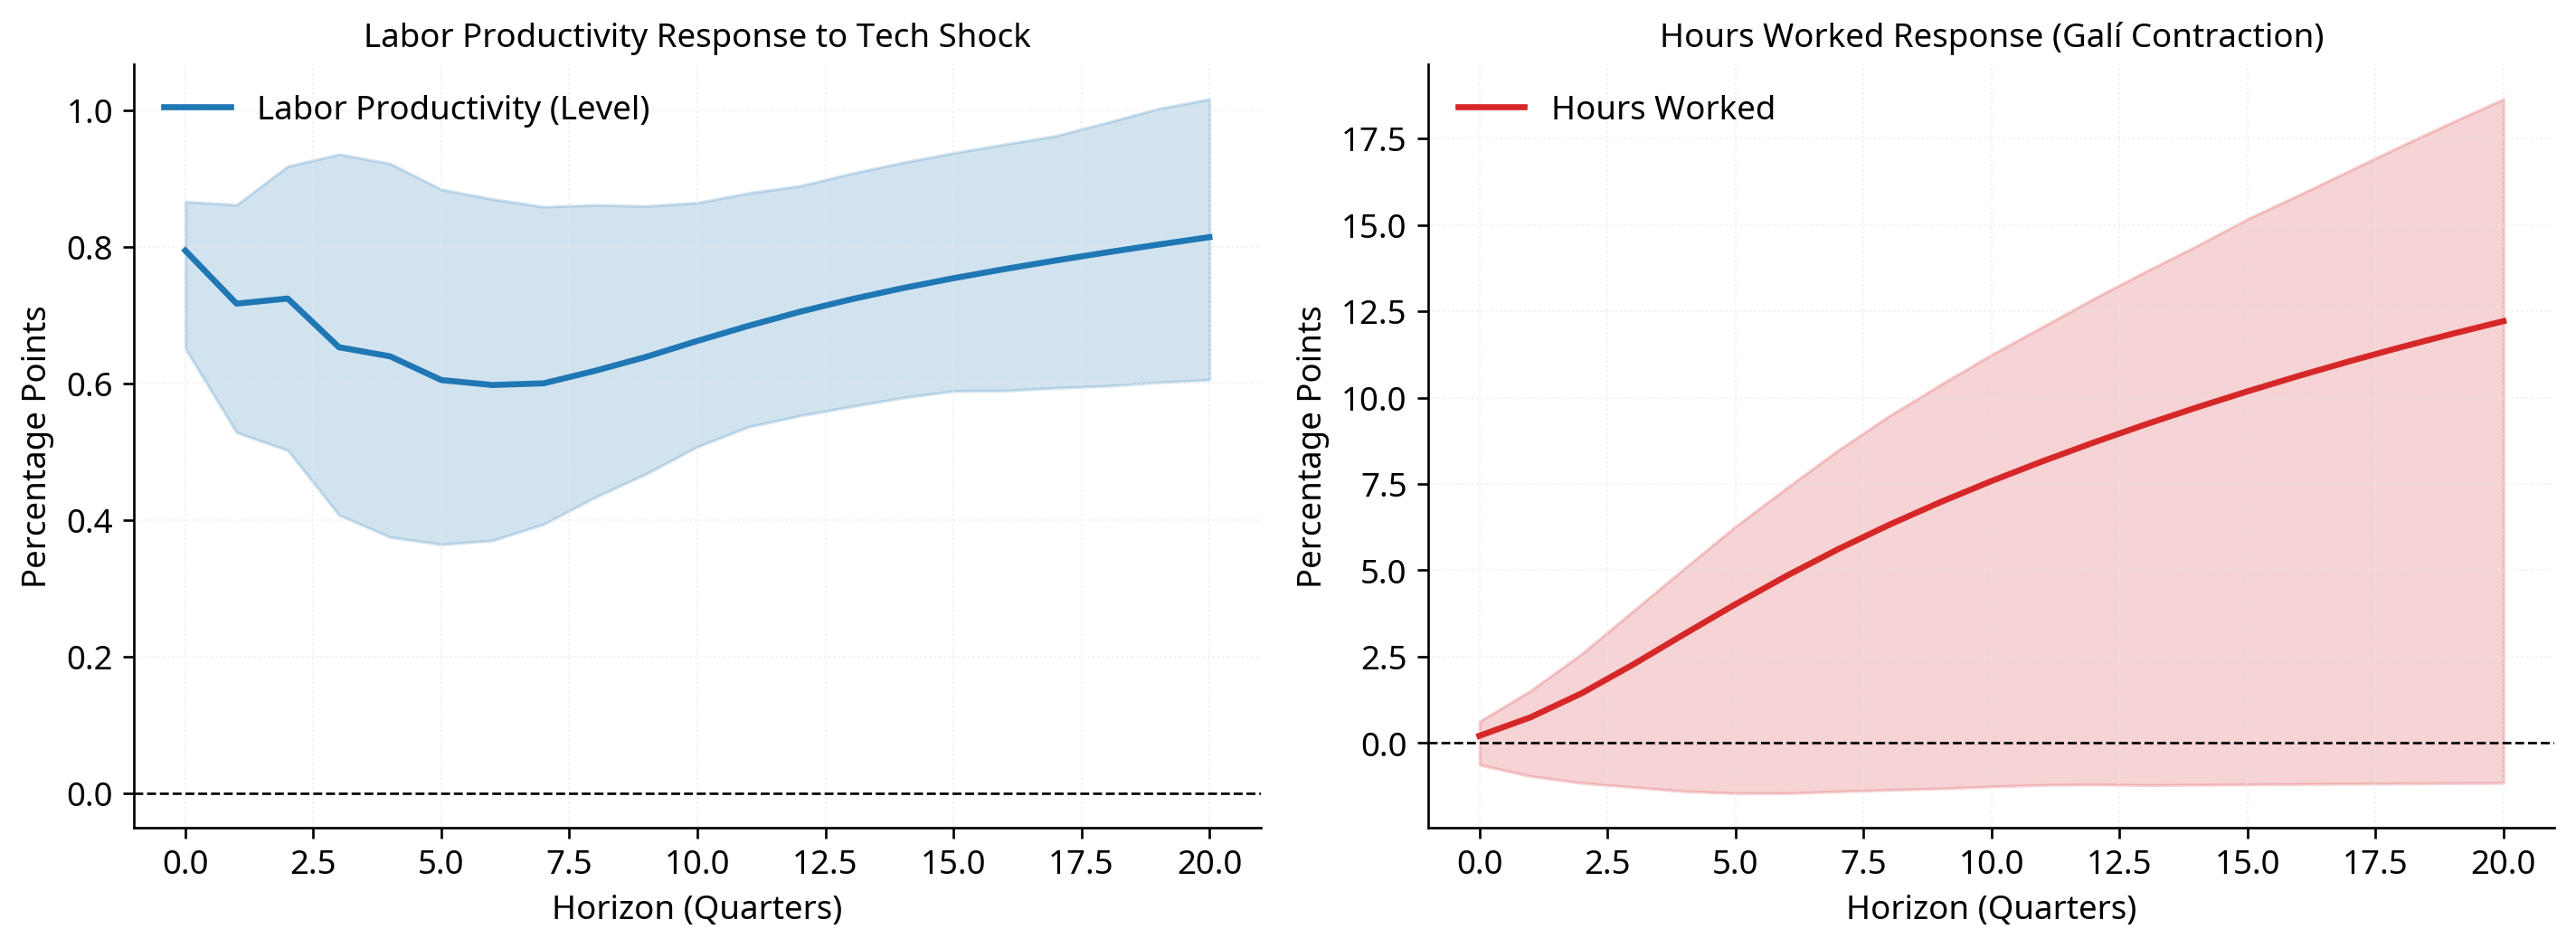

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
h_gali = np.arange(len(bq_res.irf_point))

# Panel 1: Labor Productivity (Cumulated level)
irf_prod = bq_res.irf_point[:, 0, 0]
irf_prod_lo = bq_res.irf_lower[:, 0, 0]
irf_prod_hi = bq_res.irf_upper[:, 0, 0]

ax1.plot(h_gali, irf_prod, color="#1f77b4", lw=2, label="Labor Productivity (Level)")
ax1.fill_between(h_gali, irf_prod_lo, irf_prod_hi, color="#1f77b4", alpha=0.2)
ax1.axhline(0, color="black", lw=0.8, linestyle="--")
ax1.set_title("Labor Productivity Response to Tech Shock", fontsize=11, fontweight="bold")
ax1.set_xlabel("Horizon (Quarters)")
ax1.set_ylabel("Percentage Points")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

# Panel 2: Hours Worked (Contraction on impact)
irf_hours = bq_res.irf_point[:, 1, 0]
irf_hours_lo = bq_res.irf_lower[:, 1, 0]
irf_hours_hi = bq_res.irf_upper[:, 1, 0]

ax2.plot(h_gali, irf_hours, color="#d62728", lw=2, label="Hours Worked")
ax2.fill_between(h_gali, irf_hours_lo, irf_hours_hi, color="#d62728", alpha=0.2)
ax2.axhline(0, color="black", lw=0.8, linestyle="--")
ax2.set_title("Hours Worked Response (Galí Contraction)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Horizon (Quarters)")
ax2.set_ylabel("Percentage Points")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 2. Replicating Mertens & Ravn (2013, AER): Narrative Tax Multipliers

We merge quarterly US real GDP and the Federal Funds Rate with Mertens & Ravn narrative unanticipated tax shocks.

In [4]:
df_macro_q = load_macro_quarterly()
df_tax = load_narrative_tax_shocks()

common_idx = [idx for idx in df_macro_q.index if idx in df_tax.index]
sub_macro = df_macro_q.loc[common_idx]
sub_tax = df_tax.loc[common_idx]

gdp_log = np.log(sub_macro["real_gdp"].to_numpy(dtype=float)) * 100.0
ffr = sub_macro["fed_funds"].to_numpy(dtype=float)
Z_tax = np.column_stack([gdp_log, ffr])
m_instrument = sub_tax["unanticipated"].to_numpy(dtype=float)

proxy_res = proxy(Z_tax, p=4, horizon=16, instrument_series=m_instrument, shock_target_idx=0)
print(proxy_res.summary())

ProxySVAR result
  shocks identified : 1 (column 0 of B)
  variables (n)     : 2
  horizon (H)       : 16
  bootstrap draws   : 500
  CI level          : 0.90
  first-stage F (OP): 6.79  [WEAK (use weak-IV-robust inference)]



### Impulse Responses to an Unanticipated Tax Increase

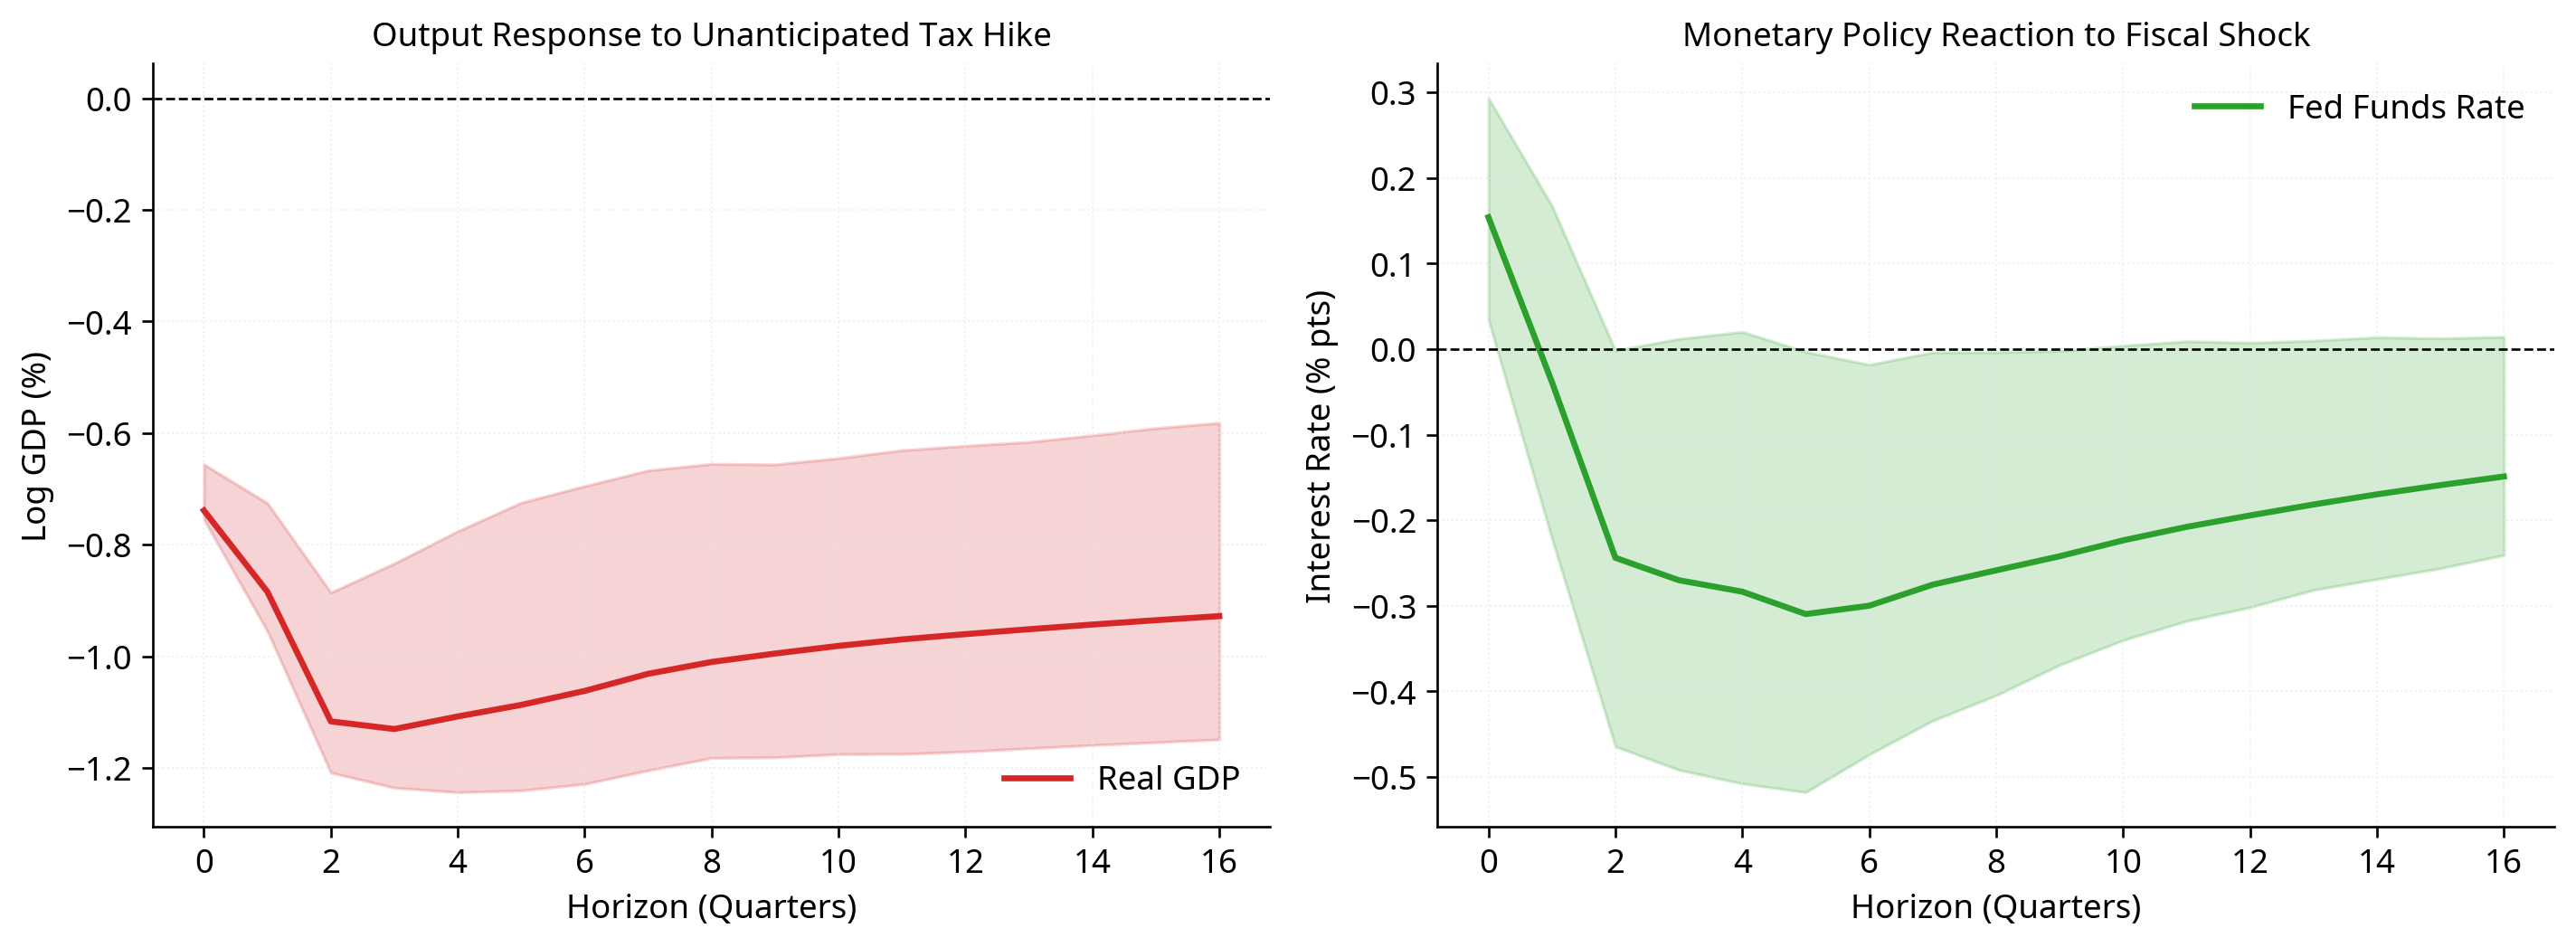

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
h_tax = np.arange(len(proxy_res.irf_point))

irf_gdp = proxy_res.irf_point[:, 0, 0]
irf_gdp_lo = proxy_res.irf_lower[:, 0, 0]
irf_gdp_hi = proxy_res.irf_upper[:, 0, 0]

ax1.plot(h_tax, irf_gdp, color="#d62728", lw=2, label="Real GDP")
ax1.fill_between(h_tax, irf_gdp_lo, irf_gdp_hi, color="#d62728", alpha=0.2)
ax1.axhline(0, color="black", lw=0.8, linestyle="--")
ax1.set_title("Output Response to Unanticipated Tax Hike", fontsize=11, fontweight="bold")
ax1.set_xlabel("Horizon (Quarters)")
ax1.set_ylabel("Log GDP (%)")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

irf_ffr = proxy_res.irf_point[:, 1, 0]
irf_ffr_lo = proxy_res.irf_lower[:, 1, 0]
irf_ffr_hi = proxy_res.irf_upper[:, 1, 0]

ax2.plot(h_tax, irf_ffr, color="#2ca02c", lw=2, label="Fed Funds Rate")
ax2.fill_between(h_tax, irf_ffr_lo, irf_ffr_hi, color="#2ca02c", alpha=0.2)
ax2.axhline(0, color="black", lw=0.8, linestyle="--")
ax2.set_title("Monetary Policy Reaction to Fiscal Shock", fontsize=11, fontweight="bold")
ax2.set_xlabel("Horizon (Quarters)")
ax2.set_ylabel("Interest Rate (% pts)")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()